In [6]:
# Cell 1: Check GPU Status
import torch

# Check for CUDA device
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU Detected: {gpu_name}")
    if "T4" not in gpu_name:
        print("⚠️ Warning: You are not using a T4 GPU. Go to Runtime > Change runtime type > T4 GPU")
else:
    print("❌ No GPU detected. Please enable GPU in Runtime > Change runtime type")

# Display NVIDIA-SMI details
!nvidia-smi

✅ GPU Detected: Tesla T4
Thu Jan  8 12:38:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------

In [7]:
# Cell 2: Install Ultralytics YOLOv8
%pip install ultralytics
import ultralytics
from ultralytics import YOLO
from IPython import display
display.clear_output()

# Verify installation
ultralytics.checks()
print("✅ Ultralytics YOLOv8 installed successfully")

Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.6/112.6 GB disk)
✅ Ultralytics YOLOv8 installed successfully


In [8]:
# Cell 3: Upload and Extract Dataset (FIXED)
import os
from google.colab import files
import shutil

# 1. Clean up previous attempts
if os.path.exists('/content/dataset'):
    shutil.rmtree('/content/dataset')
    print("Cleaned up old dataset folder.")

print("Please upload your ZIP file now...")
uploaded = files.upload()

if not uploaded:
    print("❌ No file uploaded. Please rerun this cell and select a file.")
else:
    # Get the exact filename automatically
    filename = next(iter(uploaded))
    print(f"Received file: {filename}")

    # 2. Rename file to 'dataset.zip' to avoid space issues entirely
    os.rename(filename, 'dataset.zip')
    print("Renamed to dataset.zip for safety.")

    # 3. Unzip
    print("Extracting...")
    !unzip -q "dataset.zip" -d /content/dataset

    print("✅ Dataset extracted to /content/dataset")

    # Verify what's inside immediately
    print("\nFile structure preview:")
    !ls -R /content/dataset | head -n 10

Please upload your ZIP file now...


Saving lettuce growth stage detection.v1i.yolov8.zip to lettuce growth stage detection.v1i.yolov8.zip
Received file: lettuce growth stage detection.v1i.yolov8.zip
Renamed to dataset.zip for safety.
Extracting...
✅ Dataset extracted to /content/dataset

File structure preview:
/content/dataset:
data.yaml
README.dataset.txt
README.roboflow.txt
test
train
valid

/content/dataset/test:
images


In [9]:
# Cell 4: Validate Structure & Create data.yaml
import yaml
import os

dataset_path = '/content/dataset'

# Check if Roboflow extracted into a subfolder (common issue)
# Sometimes it extracts to /content/dataset/Lettuce_Dataset/train...
contents = os.listdir(dataset_path)
if 'train' not in contents and len(contents) == 1:
    # If the only thing inside is a folder, move inside that folder
    subfolder = os.path.join(dataset_path, contents[0])
    if os.path.isdir(subfolder):
        print(f"⚠️ Dataset found inside subfolder: {subfolder}. Adjusting path...")
        dataset_path = subfolder

required_dirs = ['train/images', 'train/labels', 'valid/images', 'valid/labels']

# 1. Validation Check
missing_dirs = [d for d in required_dirs if not os.path.exists(os.path.join(dataset_path, d))]

if missing_dirs:
    print(f"❌ CURRENT CONTENTS OF {dataset_path}:")
    print(os.listdir(dataset_path))
    raise FileNotFoundError(f"❌ Missing directories: {missing_dirs}. \nCheck the output above to see where the files actually are.")
else:
    print("✅ Directory structure validated.")

# 2. Create data.yaml
# We use 'test' if it exists, otherwise we just use 'valid' for the test set
has_test = os.path.exists(os.path.join(dataset_path, 'test/images'))

yaml_content = {
    'path': dataset_path,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images' if has_test else 'valid/images',
    'nc': 4,
    'names': ['Early Growth', 'Leafy Growth', 'Head Formation', 'Harvest Stage']
}

yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f)

print(f"✅ data.yaml configured successfully at {yaml_path}")

✅ Directory structure validated.
✅ data.yaml configured successfully at /content/dataset/data.yaml


In [10]:
# Cell 5: Train YOLOv8n
from ultralytics import YOLO

# Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# Train the model
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,           # Early stopping
    augment=True,          # Default augmentation
    project='lettuce_project',
    name='yolov8n_training',
    exist_ok=True,         # Overwrite existing project folder if needed
    verbose=True
)

print("✅ Training Complete")

Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True,

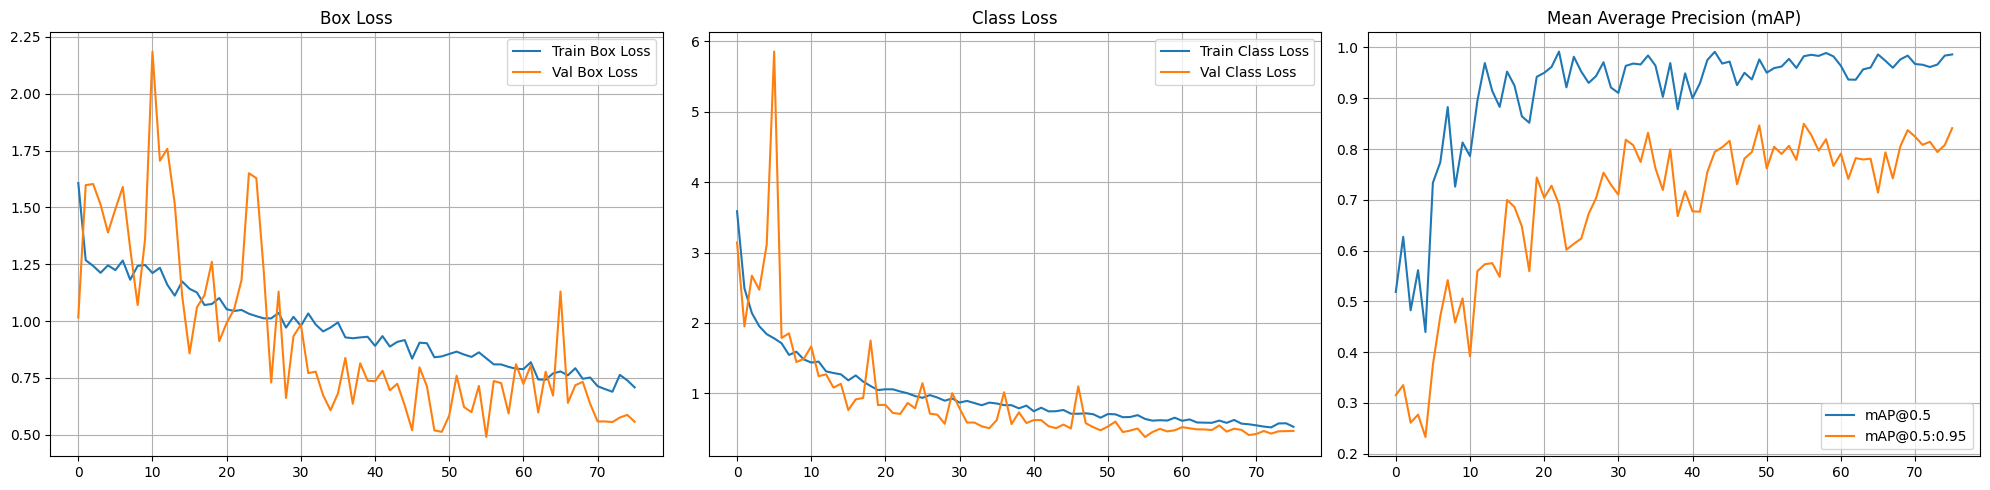

Final mAP@0.5: 0.9863
Final mAP@0.5:0.95: 0.8412


In [11]:
# Cell 6: Visualize Training Metrics (Loss & mAP)
import pandas as pd
import matplotlib.pyplot as plt

# Load results CSV
results_path = '/content/lettuce_project/yolov8n_training/results.csv'
df = pd.read_csv(results_path)
df.columns = [x.strip() for x in df.columns] # Clean column names

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# Loss Curves
axs[0].plot(df['train/box_loss'], label='Train Box Loss')
axs[0].plot(df['val/box_loss'], label='Val Box Loss')
axs[0].set_title('Box Loss')
axs[0].legend()
axs[0].grid(True)

# Class Loss
axs[1].plot(df['train/cls_loss'], label='Train Class Loss')
axs[1].plot(df['val/cls_loss'], label='Val Class Loss')
axs[1].set_title('Class Loss')
axs[1].legend()
axs[1].grid(True)

# mAP Metrics
axs[2].plot(df['metrics/mAP50(B)'], label='mAP@0.5')
axs[2].plot(df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
axs[2].set_title('Mean Average Precision (mAP)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.savefig('/content/training_metrics_summary.png')
plt.show()

print(f"Final mAP@0.5: {df['metrics/mAP50(B)'].iloc[-1]:.4f}")
print(f"Final mAP@0.5:0.95: {df['metrics/mAP50-95(B)'].iloc[-1]:.4f}")

### Evaluation Plots ###

Displaying: confusion_matrix.png


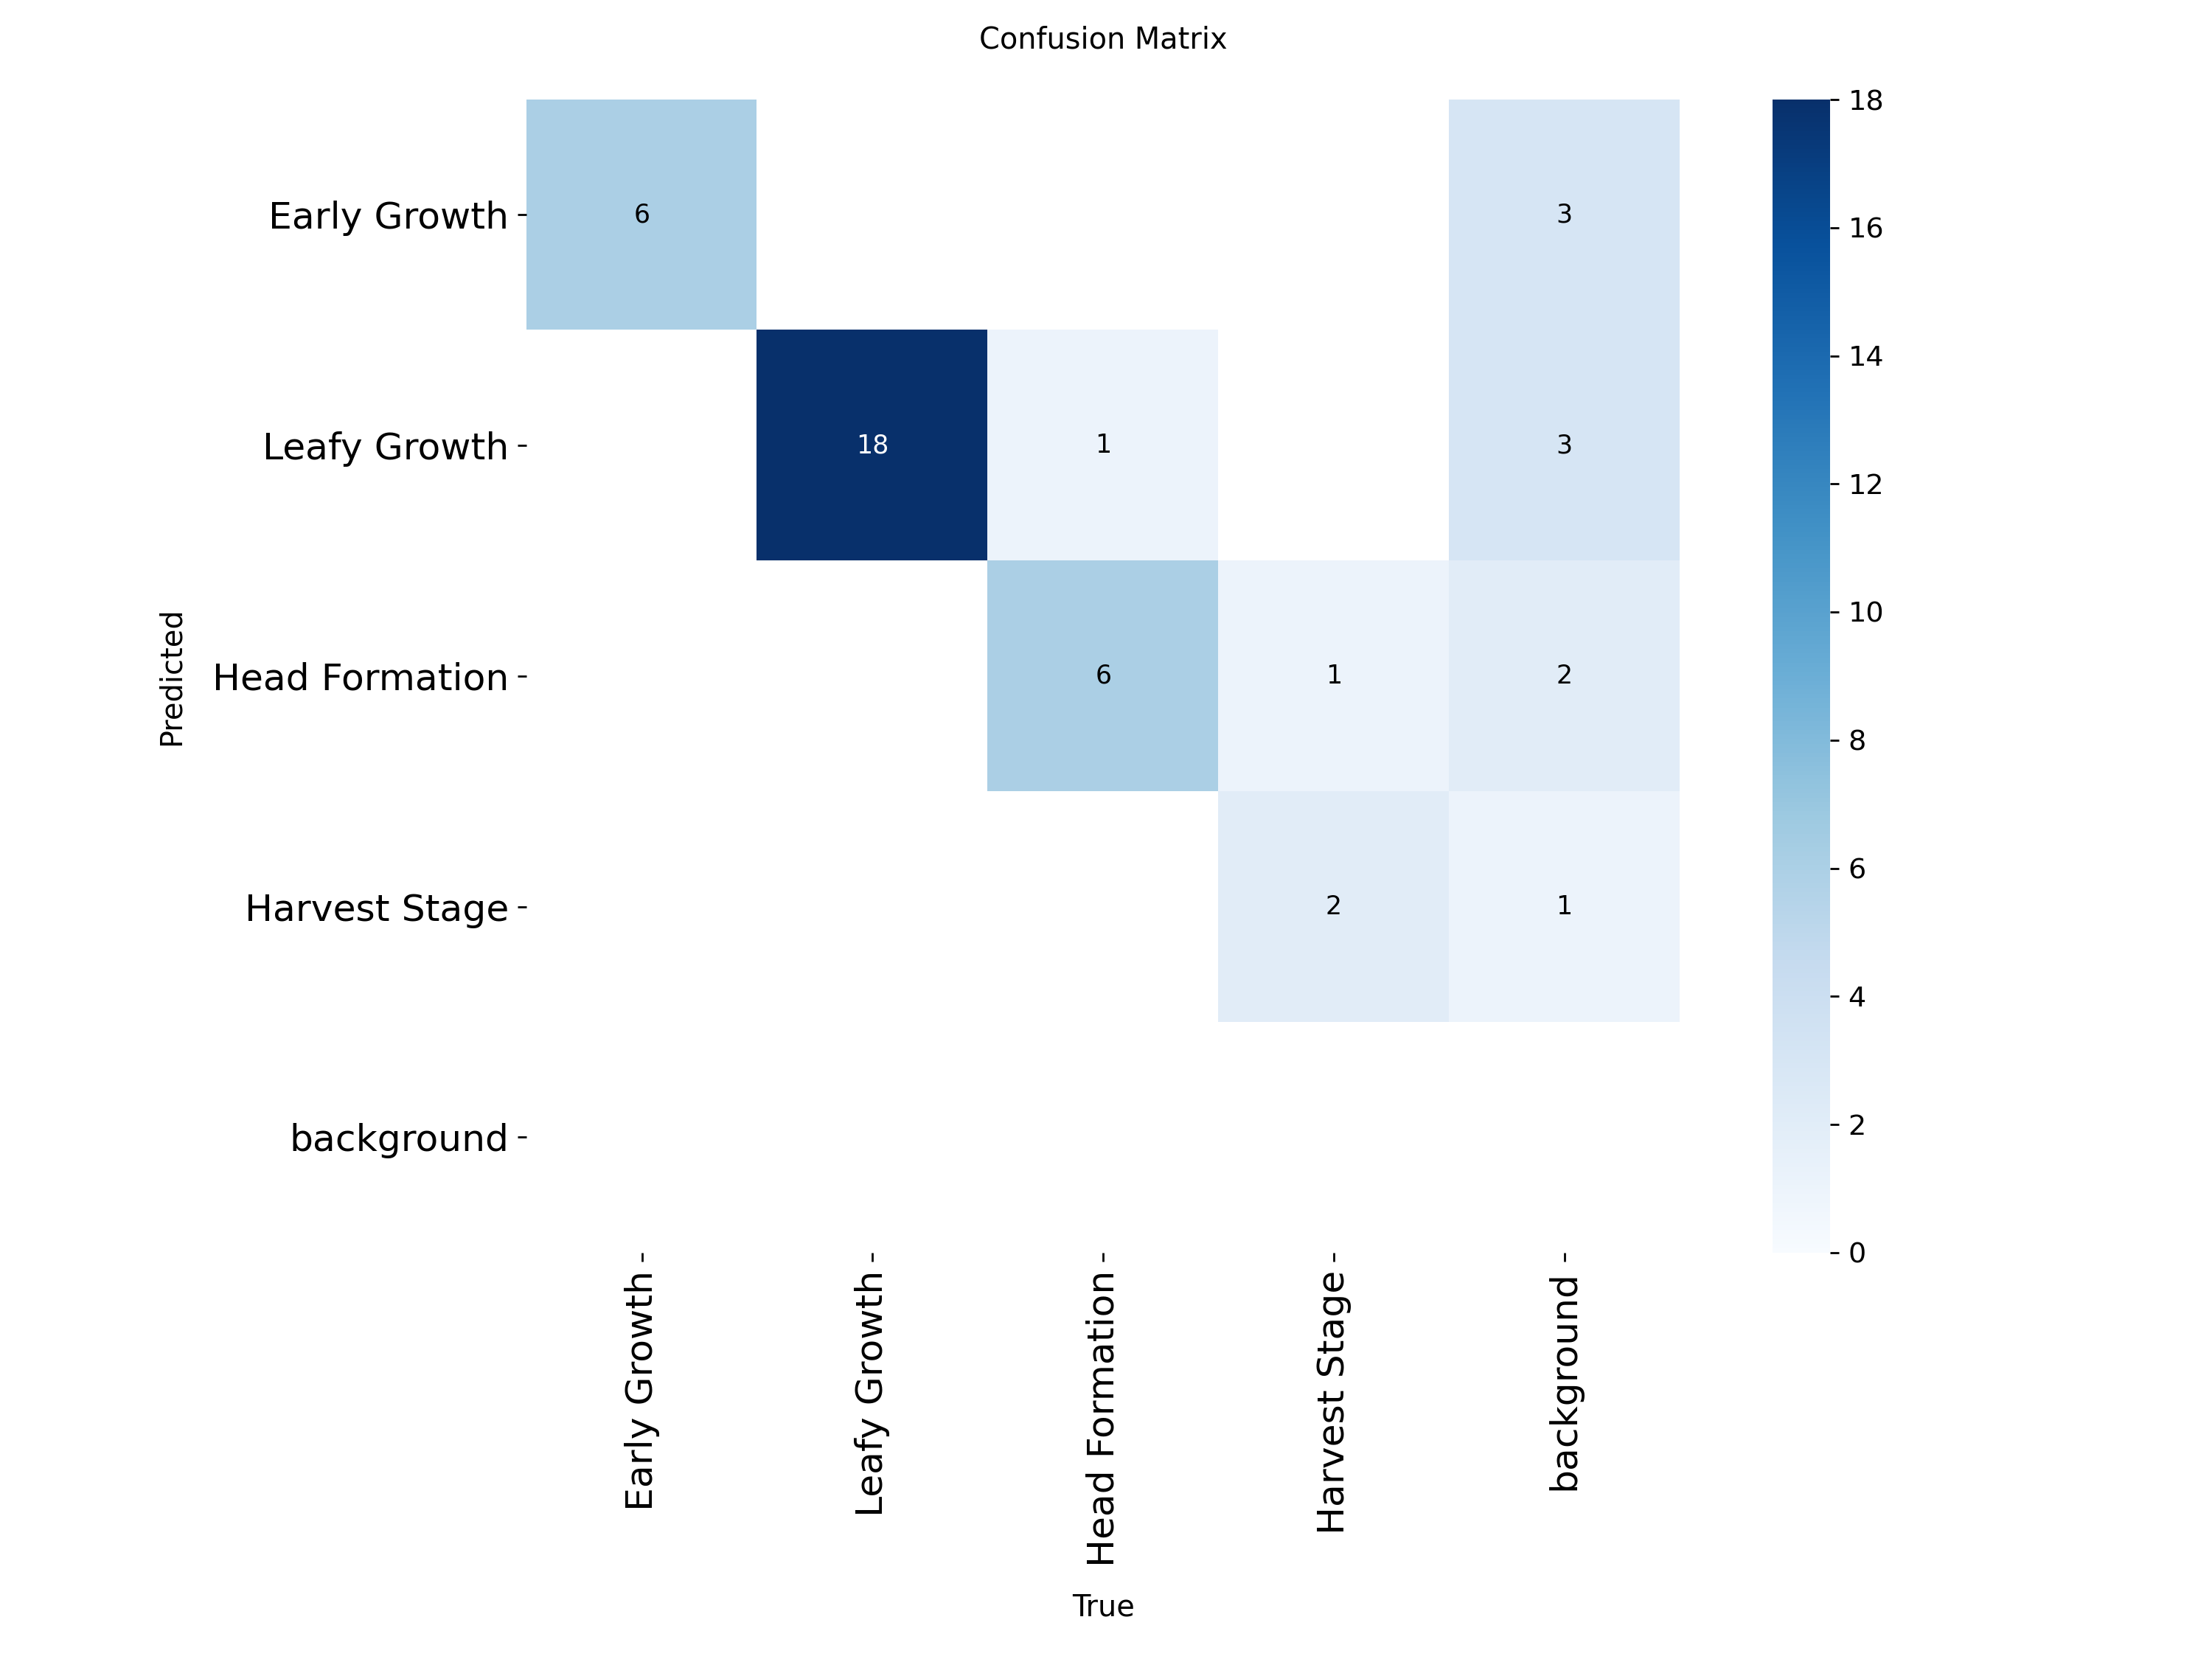

⚠️ F1_curve.png not found (Training might have been too short)
⚠️ PR_curve.png not found (Training might have been too short)

Displaying: results.png


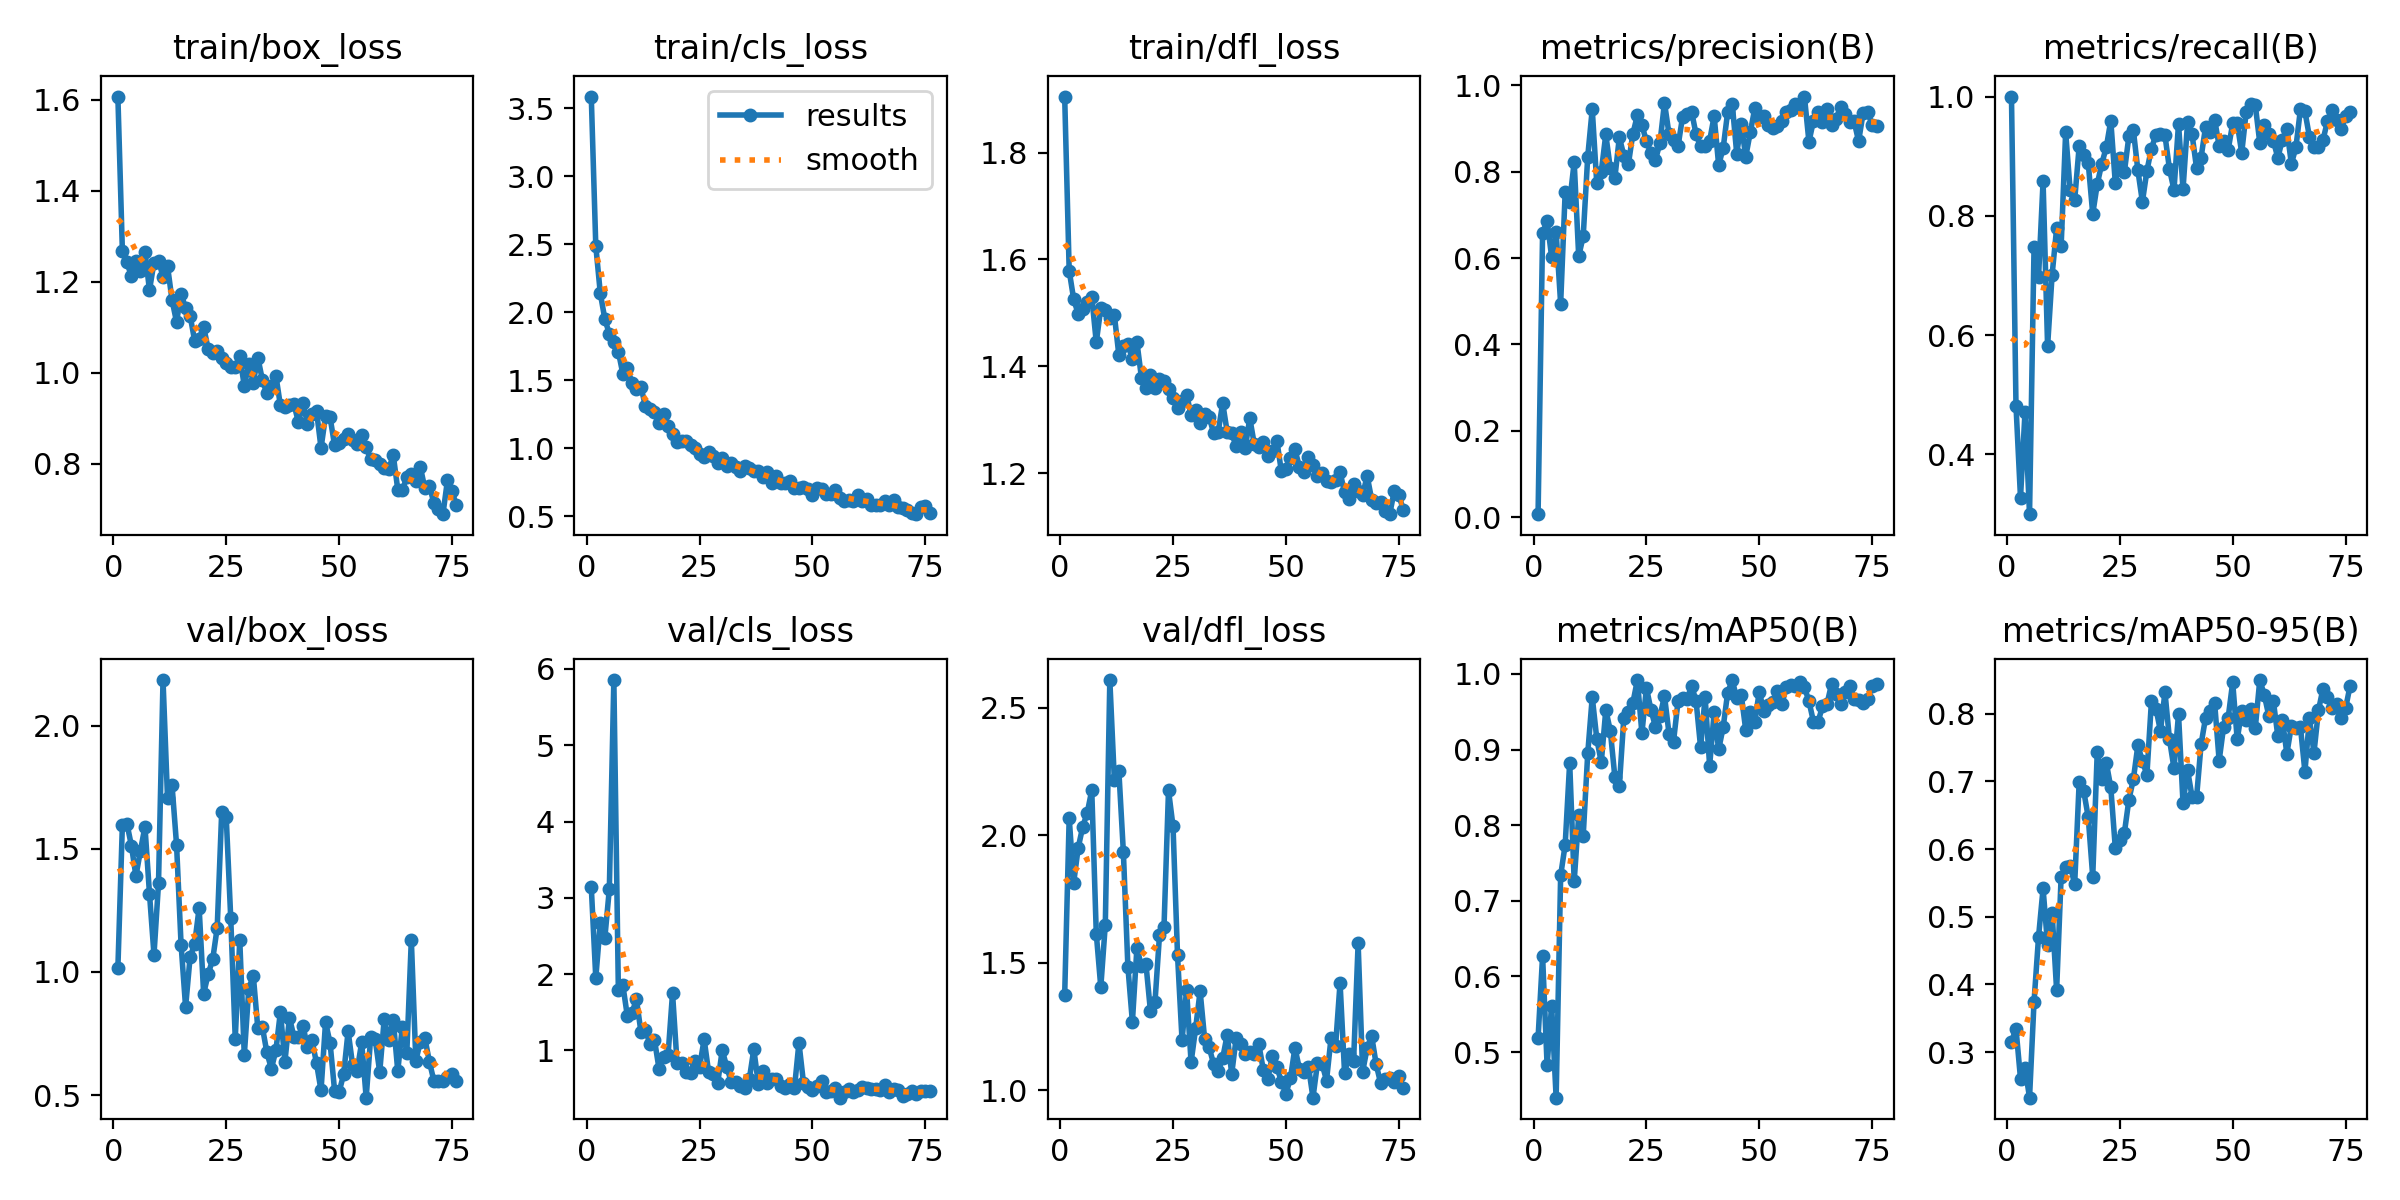

In [12]:
# Cell 7: Display Auto-Generated Evaluation Plots
from IPython.display import Image, display
import os

base_path = '/content/lettuce_project/yolov8n_training'

# List of important plots generated by YOLO
plots_to_show = [
    'confusion_matrix.png',
    'F1_curve.png',
    'PR_curve.png',
    'results.png'
]

print("### Evaluation Plots ###")
for plot_name in plots_to_show:
    plot_path = os.path.join(base_path, plot_name)
    if os.path.exists(plot_path):
        print(f"\nDisplaying: {plot_name}")
        display(Image(filename=plot_path, width=600))
    else:
        print(f"⚠️ {plot_name} not found (Training might have been too short)")

In [13]:
# Cell 8: Inference on Test Set
# Load best weights
best_model = YOLO('/content/lettuce_project/yolov8n_training/weights/best.pt')

# Run prediction
print("Running inference on Test set...")
test_results = best_model.predict(
    source='/content/dataset/test/images',
    save=True,
    conf=0.25,      # Confidence threshold
    iou=0.45,       # NMS threshold
    project='lettuce_project',
    name='test_predictions',
    exist_ok=True
)

print(f"✅ Inference complete. Results saved to /content/lettuce_project/test_predictions")

Running inference on Test set...

image 1/17 /content/dataset/test/images/20230123_091505_jpg.rf.88562b099481e1b5b0233b5ce4078b63.jpg: 640x640 1 Early Growth, 7.1ms
image 2/17 /content/dataset/test/images/20230123_092028_jpg.rf.f5b5a8ca4836f93841b8e7cc202c16d5.jpg: 640x640 1 Early Growth, 7.5ms
image 3/17 /content/dataset/test/images/20230125_100757_jpg.rf.07029fc15f249a46e171c4c5c8fe1a1b.jpg: 640x640 1 Early Growth, 7.1ms
image 4/17 /content/dataset/test/images/20230202_093914_jpg.rf.619ccd271b32574ebf08e04f348278cc.jpg: 640x640 1 Leafy Growth, 7.2ms
image 5/17 /content/dataset/test/images/20230202_093948_jpg.rf.6535340743ec2d9d3ebfe4203cca4cd1.jpg: 640x640 2 Leafy Growths, 7.2ms
image 6/17 /content/dataset/test/images/20230202_094037_jpg.rf.fcc59bf1d40388e383c8deb0f462f876.jpg: 640x640 1 Leafy Growth, 7.2ms
image 7/17 /content/dataset/test/images/20230202_094331_jpg.rf.e9692ad5b61c6d3ab57b12f0d14427fd.jpg: 640x640 1 Leafy Growth, 7.2ms
image 8/17 /content/dataset/test/images/IMG_2023

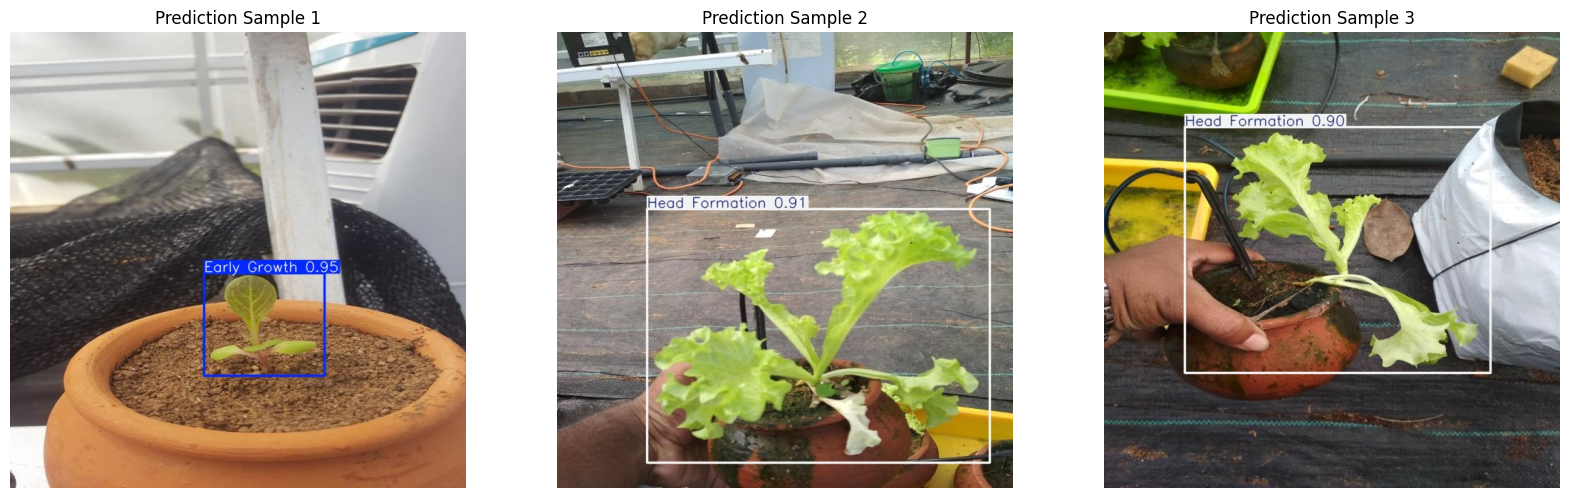

In [14]:
# Cell 9: Visualize Sample Predictions
import glob
import random
from PIL import Image as PILImage

# Get list of predicted images
pred_images = glob.glob('/content/lettuce_project/test_predictions/*.jpg') + \
              glob.glob('/content/lettuce_project/test_predictions/*.png')

if not pred_images:
    print("No prediction images found.")
else:
    # Display 3 random images
    samples = random.sample(pred_images, min(3, len(pred_images)))

    plt.figure(figsize=(20, 10))
    for i, img_path in enumerate(samples):
        img = PILImage.open(img_path)
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction Sample {i+1}")
    plt.show()

In [15]:
# Cell 10: Zip and Download Results
import shutil
from google.colab import files

output_zip = '/content/Lettuce_YOLOv8_Results.zip'
project_dir = '/content/lettuce_project'

print("Zipping training results...")
shutil.make_archive('/content/Lettuce_YOLOv8_Results', 'zip', project_dir)

print(f"✅ Archive created at {output_zip}")
print("Starting download...")

files.download(output_zip)

Zipping training results...
✅ Archive created at /content/Lettuce_YOLOv8_Results.zip
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>